### Importación de datos



In [3]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


In [5]:
tienda.info()
tienda.describe()
tienda.columns

<class 'pandas.DataFrame'>
RangeIndex: 2359 entries, 0 to 2358
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Producto                2359 non-null   str    
 1   Categoría del Producto  2359 non-null   str    
 2   Precio                  2359 non-null   float64
 3   Costo de envío          2359 non-null   float64
 4   Fecha de Compra         2359 non-null   str    
 5   Vendedor                2359 non-null   str    
 6   Lugar de Compra         2359 non-null   str    
 7   Calificación            2359 non-null   int64  
 8   Método de pago          2359 non-null   str    
 9   Cantidad de cuotas      2359 non-null   int64  
 10  lat                     2359 non-null   float64
 11  lon                     2359 non-null   float64
dtypes: float64(4), int64(2), str(6)
memory usage: 221.3 KB


Index(['Producto', 'Categoría del Producto', 'Precio', 'Costo de envío',
       'Fecha de Compra', 'Vendedor', 'Lugar de Compra', 'Calificación',
       'Método de pago', 'Cantidad de cuotas', 'lat', 'lon'],
      dtype='str')

#1. Análisis de facturación



In [4]:
ingreso1 = tienda['Precio'].sum()
ingreso2 = tienda2['Precio'].sum()
ingreso3 = tienda3['Precio'].sum()
ingreso4 = tienda4['Precio'].sum()

ingresos = pd.DataFrame({
    'Tienda': ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4'],
    'Ingreso Total': [ingreso1, ingreso2, ingreso3, ingreso4]
})

ingresos

,Tienda,Ingreso Total
0,Tienda 1,1.150880e+09
1,Tienda 2,1.116344e+09
2,Tienda 3,1.098020e+09
3,Tienda 4,1.038376e+09


GRÁFICO 1 — INGRESOS (BARRAS)

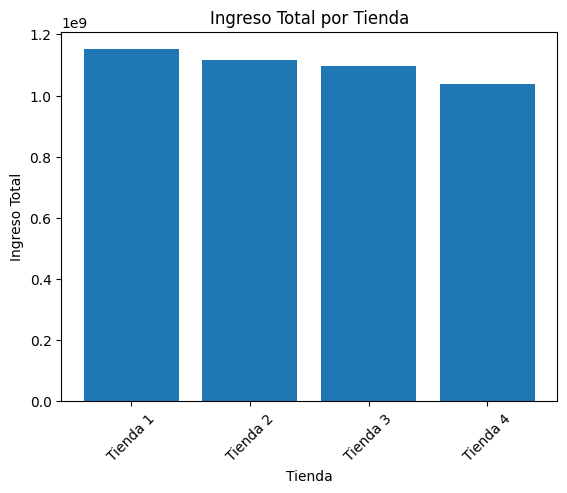

In [6]:
plt.figure()
plt.bar(ingresos['Tienda'], ingresos['Ingreso Total'])
plt.title('Ingreso Total por Tienda')
plt.xlabel('Tienda')
plt.ylabel('Ingreso Total')
plt.xticks(rotation=45)
plt.show()

# 2. Ventas por categoría

In [9]:
categoria1 = tienda.groupby('Categoría del Producto')['Producto'].count().sort_values(ascending=False)
categoria2 = tienda2.groupby('Categoría del Producto')['Producto'].count().sort_values(ascending=False)
categoria3 = tienda3.groupby('Categoría del Producto')['Producto'].count().sort_values(ascending=False)
categoria4 = tienda4.groupby('Categoría del Producto')['Producto'].count().sort_values(ascending=False)

categoria1

Categoría del Producto
Muebles                    465
Electrónicos               448
Juguetes                   324
Electrodomésticos          312
Deportes y diversión       284
Instrumentos musicales     182
Libros                     173
Artículos para el hogar    171
Name: Producto, dtype: int64

# 3. Calificación promedio de la tienda


In [11]:
valoracion1 = tienda['Calificación'].mean()
valoracion2 = tienda2['Calificación'].mean()
valoracion3 = tienda3['Calificación'].mean()
valoracion4 = tienda4['Calificación'].mean()

valoraciones = pd.DataFrame({
    'Tienda': ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4'],
    'Valoración Promedio': [valoracion1, valoracion2, valoracion3, valoracion4]
})

valoraciones

,Tienda,Valoración Promedio
0,Tienda 1,3.976685
1,Tienda 2,4.037304
2,Tienda 3,4.048326
3,Tienda 4,3.995759


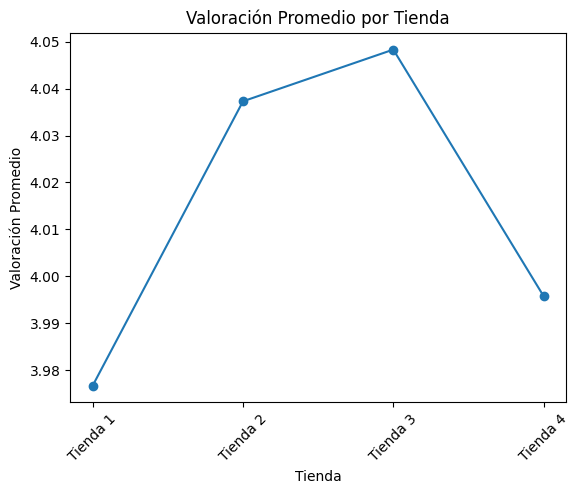

In [12]:
plt.figure()
plt.plot(valoraciones['Tienda'], valoraciones['Valoración Promedio'], marker='o')
plt.title('Valoración Promedio por Tienda')
plt.xlabel('Tienda')
plt.ylabel('Valoración Promedio')
plt.xticks(rotation=45)
plt.show()

# 4. Productos más y menos vendidos

 Para Tienda 1


In [14]:
mas_vendido1 = tienda['Producto'].value_counts().head(1)
menos_vendido1 = tienda['Producto'].value_counts().tail(1)

print("Más vendido:")
print(mas_vendido1)

print("\nMenos vendido:")
print(menos_vendido1)

Más vendido:
Producto
Microondas    60
Name: count, dtype: int64

Menos vendido:
Producto
Celular ABXY    33
Name: count, dtype: int64


Para Tienda 2

In [16]:
mas_vendido2 = tienda2['Producto'].value_counts().head(1)
menos_vendido2 = tienda2['Producto'].value_counts().tail(1)

print("Más vendido:")
print(mas_vendido2)

print("\nMenos vendido:")
print(menos_vendido2)

Más vendido:
Producto
Iniciando en programación    65
Name: count, dtype: int64

Menos vendido:
Producto
Juego de mesa    32
Name: count, dtype: int64


Para Tienda 3

In [17]:
mas_vendido3 = tienda3['Producto'].value_counts().head(1)
menos_vendido3 = tienda3['Producto'].value_counts().tail(1)

print("Más vendido:")
print(mas_vendido3)
print("\nMenos vendido:")
print(menos_vendido3)

Más vendido:
Producto
Kit de bancas    57
Name: count, dtype: int64

Menos vendido:
Producto
Bloques de construcción    35
Name: count, dtype: int64


Para Tienda 4

In [18]:
mas_vendido4 = tienda4['Producto'].value_counts().head(1)
menos_vendido4 = tienda4['Producto'].value_counts().tail(1)

print("Más vendido:")
print(mas_vendido4)
print("\nMenos vendido:")
print(menos_vendido4)

Más vendido:
Producto
Cama box    62
Name: count, dtype: int64

Menos vendido:
Producto
Guitarra eléctrica    33
Name: count, dtype: int64


In [19]:
tiendas = [tienda, tienda2, tienda3, tienda4]

for i, t in enumerate(tiendas, start=1):
    print(f"\nTienda {i}")
    print("Más vendido:")
    print(t['Producto'].value_counts().head(1))
    
    print("Menos vendido:")
    print(t['Producto'].value_counts().tail(1))


Tienda 1
Más vendido:
Producto
Microondas    60
Name: count, dtype: int64
Menos vendido:
Producto
Celular ABXY    33
Name: count, dtype: int64

Tienda 2
Más vendido:
Producto
Iniciando en programación    65
Name: count, dtype: int64
Menos vendido:
Producto
Juego de mesa    32
Name: count, dtype: int64

Tienda 3
Más vendido:
Producto
Kit de bancas    57
Name: count, dtype: int64
Menos vendido:
Producto
Bloques de construcción    35
Name: count, dtype: int64

Tienda 4
Más vendido:
Producto
Cama box    62
Name: count, dtype: int64
Menos vendido:
Producto
Guitarra eléctrica    33
Name: count, dtype: int64


# 5. Envío promedio por tienda

In [20]:
envio1 = tienda['Costo de envío'].mean()
envio2 = tienda2['Costo de envío'].mean()
envio3 = tienda3['Costo de envío'].mean()
envio4 = tienda4['Costo de envío'].mean()

envios = pd.DataFrame({
    'Tienda': ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4'],
    'Envio Promedio': [envio1, envio2, envio3, envio4]
})

envios

,Tienda,Envio Promedio
0,Tienda 1,26018.609580
1,Tienda 2,25216.235693
2,Tienda 3,24805.680373
3,Tienda 4,23459.457167


GRÁFICO 3 — ENVÍO PROMEDIO (DISPERSIÓN)

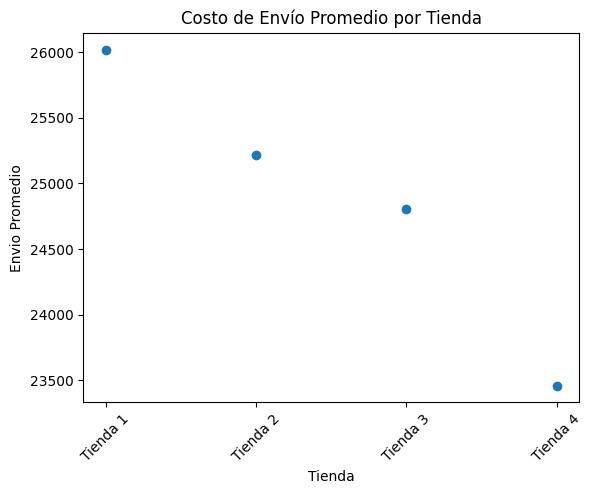

In [21]:
plt.figure()
plt.scatter(envios['Tienda'], envios['Envio Promedio'])
plt.title('Costo de Envío Promedio por Tienda')
plt.xlabel('Tienda')
plt.ylabel('Envio Promedio')
plt.xticks(rotation=45)
plt.show()

EXTRA — ANÁLISIS GEOGRÁFICO (OPCIONAL)

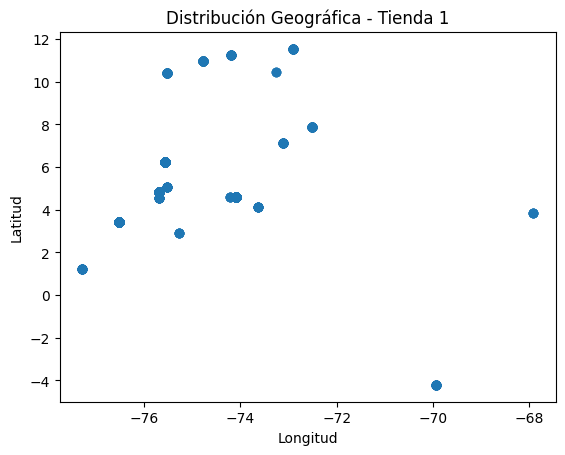

In [22]:
plt.figure()
plt.scatter(tienda['lon'], tienda['lat'])
plt.title('Distribución Geográfica - Tienda 1')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.show()

# 📊 Informe Final – Análisis de Tiendas

## Introducción

El objetivo de este análisis fue evaluar el desempeño de cuatro tiendas a partir de sus datos de ventas, considerando ingresos totales, categorías más vendidas, satisfacción del cliente, productos destacados y costos de envío.

## Desarrollo

### Ingresos Totales
Se compararon los ingresos totales de cada tienda, observando que la tienda con mayor facturación fue 1.150880e+09 en la tienda 1.

### Ventas por Categoría
Las categorías más vendidas fueron Categoría del Producto Muebles 4654 lo que demuestra una alta demanda en esos segmentos.

### Valoración Promedio
La tienda con mejor calificación promedio fue Tienda 3 con	4.048326, indicando mayor satisfacción del cliente.

### Productos Destacados
El producto más vendido en la tienda1 fue microondas, mientras que el menos vendido fue celular ABXY.
El producto más vendido  en la tienda2 fue iniciando programacion, mientras que el menos vendido fue juego de mesa.
El producto más vendido en la tienda3 fue kit de banco, mientras que el menos vendido fue bloque de construción.
El producto más vendido en la tienda4 fue cama box, mientras que el menos vendido fue guitarra electrica.

### Costo de Envío
El costo promedio de envío fue menor en la Tienda 4 de 23459.457167, lo cual representa una ventaja competitiva considerando que el cliente paga el envío.


## Conclusión

Luego de analizar todos los factores, se recomienda vender en la **Tienda 1**, ya que presenta el mayor ingreso total entre todas las tiendas analizadas, lo que indica un alto volumen de ventas y una fuerte demanda del mercado.

Si bien la Tienda 3 posee la mejor calificación promedio y la Tienda 4 presenta el menor costo de envío, la Tienda 1 ofrece el mejor equilibrio general entre facturación, diversidad de productos vendidos y posicionamiento en el mercado.

Por lo tanto, desde una perspectiva estratégica y financiera, la Tienda 1 representa la opción más rentable y con mayor potencial de crecimiento.